# 路线偏好训练数据诊断

这个 notebook 用于判断当前路线偏好 MLP 是应该继续调参，还是优先补数据。

- 只读 PostgreSQL 和训练产物，不写数据库。
- 复用 `training/` 里的数据构造、candidate_set 切分和模型定义，避免诊断口径和训练口径不一致。
- 图表重点看 candidate set 数量、pair 数量、accepted/rejected 分布、reason code 支持度、训练 history，以及当前模型的 reason 分数分布。


In [43]:
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

try:
    import pandas as pd
except ImportError:
    pd = None


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "AGENTS.md").exists() and (path / "ai-python" / "src").exists():
            return path
    raise RuntimeError("找不到项目根目录，请从 urban-sidequest 项目内打开 notebook。")


PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "ai-python" / "src"
SRC_ROOT_TEXT = str(SRC_ROOT)
sys.path = [SRC_ROOT_TEXT] + [entry for entry in sys.path if entry != SRC_ROOT_TEXT]
for module_name in list(sys.modules):
    if module_name == "urban_sidequest_ai" or module_name.startswith("urban_sidequest_ai."):
        del sys.modules[module_name]

OUTPUT_DIR = PROJECT_ROOT / "tmp" / "route-pref-training-output"
FEATURE_SCHEMA_VERSION = "route_pref_v5"
SEED = 42

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def show_table(rows: list[dict], title: str | None = None, sort_by: str | None = None):
    if title:
        display(Markdown(f"### {title}"))
    if not rows:
        display(Markdown("无数据"))
        return None
    if pd is not None:
        frame = pd.DataFrame(rows)
        if sort_by and sort_by in frame.columns:
            frame = frame.sort_values(sort_by, ascending=False)
        display(frame)
        return frame
    for row in rows:
        print(row)
    return rows


display(Markdown(f"项目根目录：`{PROJECT_ROOT}`"))
display(Markdown(f"训练产物目录：`{OUTPUT_DIR}`"))


项目根目录：`/Users/qinzeyu/study/mix-java-python/urban-sidequest`

训练产物目录：`/Users/qinzeyu/study/mix-java-python/urban-sidequest/tmp/route-pref-training-output`

In [44]:
from urban_sidequest_ai.models.route_preference.training.db import connect, load_database_config
from urban_sidequest_ai.models.route_preference.training.dataset import (
    build_dataset_bundle,
    iter_batches,
    split_by_candidate_set,
)
from urban_sidequest_ai.models.route_preference.training.model import RoutePreferenceModel, RoutePreferenceModelConfig
from urban_sidequest_ai.models.route_preference.training.repository import RoutePreferenceTrainingRepository
from urban_sidequest_ai.models.route_preference.training.schema import (
    DEFAULT_GOOD_ROUTE_THRESHOLD,
    DEFAULT_HIGH_ISSUE_THRESHOLD,
    DEFAULT_ISSUE_THRESHOLD,
    InvalidJudgmentPolicy,
    REASON_CODES,
)


def load_bundle():
    db_config = load_database_config()
    with connect(db_config) as connection:
        repository = RoutePreferenceTrainingRepository(connection)
        sample_rows = repository.fetch_training_samples(FEATURE_SCHEMA_VERSION)
        judgment_rows = repository.fetch_completed_judgments({row.candidate_set_id for row in sample_rows})
    bundle = build_dataset_bundle(sample_rows, judgment_rows, InvalidJudgmentPolicy.FAIL)
    splits = split_by_candidate_set(bundle.groups, seed=SEED)
    return sample_rows, judgment_rows, bundle, splits


sample_rows, judgment_rows, bundle, splits = load_bundle()
SPLIT_GROUPS = {
    "train": splits.train,
    "valid": splits.valid,
    "test": splits.test,
}

display(Markdown(f"读取训练样本 `{len(sample_rows)}` 行，completed judgments `{len(judgment_rows)}` 条，可训练 candidate sets `{len(bundle.groups)}` 组。"))
if bundle.skipped_judgments:
    display(Markdown(f"跳过 judgment 数：`{len(bundle.skipped_judgments)}`"))
    for message in bundle.skipped_judgments[:10]:
        print(message)


读取训练样本 `9226` 行，completed judgments `3088` 条，可训练 candidate sets `1919` 组。

### Split 总览

,split,candidate_sets,routes,pairs,avg_routes_per_set,avg_pairs_per_set,accepted_routes,rejected_routes,goodness_labeled_routes,reason_labeled_routes
0,train,1373,6592,10669,4.80,7.77,2439,2545,4984,2545
1,valid,302,1424,2266,4.72,7.50,524,568,1092,568
2,test,244,1149,1839,4.71,7.54,421,443,864,443


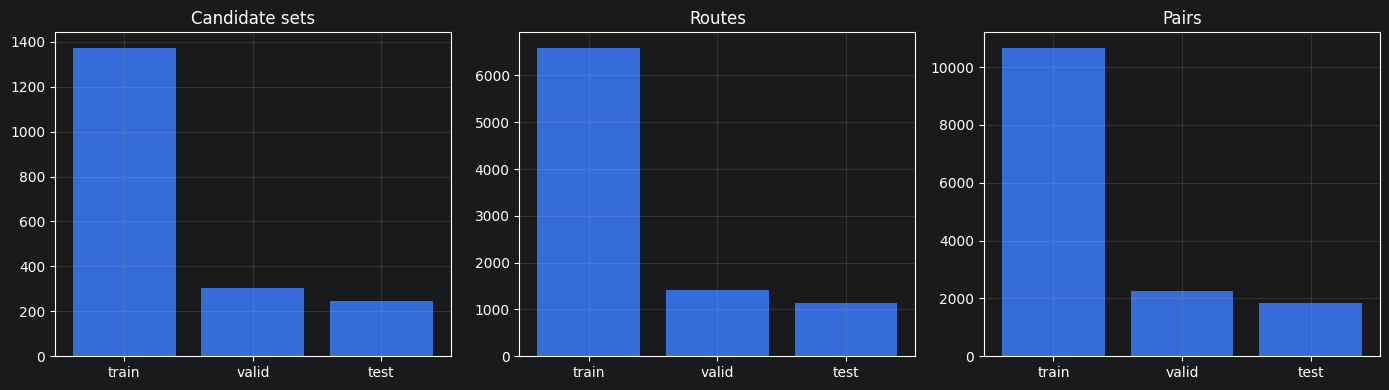

In [45]:
def summarize_split(groups):
    route_count = sum(len(group.items) for group in groups)
    pair_count = sum(len(group.pairs) for group in groups)
    accepted_count = sum(1 for group in groups for item in group.items if item.is_accepted)
    rejected_count = sum(1 for group in groups for item in group.items if item.is_rejected)
    goodness_labeled = sum(1 for group in groups for item in group.items if item.goodness_mask)
    reason_labeled = sum(1 for group in groups for item in group.items if item.reason_mask)
    return {
        "candidate_sets": len(groups),
        "routes": route_count,
        "pairs": pair_count,
        "avg_routes_per_set": round(route_count / len(groups), 2) if groups else 0.0,
        "avg_pairs_per_set": round(pair_count / len(groups), 2) if groups else 0.0,
        "accepted_routes": accepted_count,
        "rejected_routes": rejected_count,
        "goodness_labeled_routes": goodness_labeled,
        "reason_labeled_routes": reason_labeled,
    }


split_rows = [{"split": split_name, **summarize_split(groups)} for split_name, groups in SPLIT_GROUPS.items()]
show_table(split_rows, "Split 总览")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = [row["split"] for row in split_rows]
axes[0].bar(x, [row["candidate_sets"] for row in split_rows])
axes[0].set_title("Candidate sets")
axes[1].bar(x, [row["routes"] for row in split_rows])
axes[1].set_title("Routes")
axes[2].bar(x, [row["pairs"] for row in split_rows])
axes[2].set_title("Pairs")
plt.tight_layout()
plt.show()


In [46]:
def distribution_rows(counter: Counter, key_name: str, split_name: str):
    total = sum(counter.values())
    return [
        {
            "split": split_name,
            key_name: key,
            "count": count,
            "pct": round(count / total, 4) if total else 0.0,
        }
        for key, count in counter.items()
    ]


judge_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    judge_rows.extend(distribution_rows(Counter(group.judge_type for group in groups), "judge_type", split_name))

show_table(judge_rows, "judge_type 分布", "count")


### judge_type 分布

,split,judge_type,count,pct
0,train,LLM_SIM_USER,1373,1.0
1,valid,LLM_SIM_USER,302,1.0
2,test,LLM_SIM_USER,244,1.0


,split,judge_type,count,pct
0,train,LLM_SIM_USER,1373,1.0
1,valid,LLM_SIM_USER,302,1.0
2,test,LLM_SIM_USER,244,1.0


### train 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,train,1,358
1,train,2,1052
2,train,3,748
3,train,4,298
4,train,5,73
5,train,6,15
6,train,7,1


### valid 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,valid,1,86
1,valid,2,246
2,valid,3,156
3,valid,4,57
4,valid,5,19
5,valid,6,3
6,valid,7,1


### test 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,test,1,62
1,test,2,186
2,test,3,126
3,test,4,45
4,test,5,19
5,test,6,4
6,test,7,1


### reason code 正样本支持度

,split,reason_code,positive_routes,positive_rate_in_reason_routes,positive_rate_in_rejected
3,train,HIGH_FATIGUE,1047,0.4114,0.4114
0,train,LOW_INTEREST_COVERAGE,958,0.3764,0.3764
6,train,REPETITIVE_POI_TYPE,914,0.3591,0.3591
2,train,BAD_TIME_STRUCTURE,800,0.3143,0.3143
7,train,BUDGET_MISMATCH,704,0.2766,0.2766
1,train,WEAK_GOAL_FIT,675,0.2652,0.2652
5,train,LOW_ROUTE_DIVERSITY,629,0.2472,0.2472
4,train,BAD_SPATIAL_FLOW,489,0.1921,0.1921
12,valid,HIGH_FATIGUE,218,0.3838,0.3838
15,valid,REPETITIVE_POI_TYPE,214,0.3768,0.3768


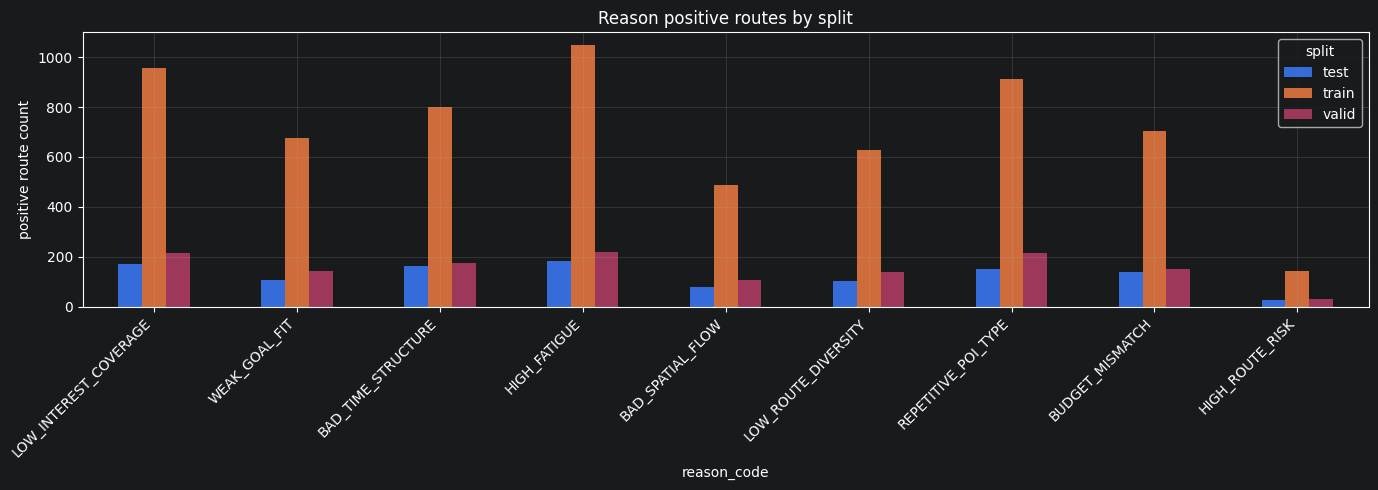

In [47]:
reason_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    reason_route_count = sum(1 for group in groups for item in group.items if item.reason_mask)
    rejected_count = sum(1 for group in groups for item in group.items if item.is_rejected)
    positives = Counter()
    cooccurrence = Counter()
    for group in groups:
        for item in group.items:
            if not item.reason_mask:
                continue
            active_codes = [REASON_CODES[index] for index, value in enumerate(item.reason_labels) if value >= 0.5]
            positives.update(active_codes)
            cooccurrence[len(active_codes)] += 1
    for code in REASON_CODES:
        count = positives[code]
        reason_rows.append(
            {
                "split": split_name,
                "reason_code": code,
                "positive_routes": count,
                "positive_rate_in_reason_routes": round(count / reason_route_count, 4) if reason_route_count else 0.0,
                "positive_rate_in_rejected": round(count / rejected_count, 4) if rejected_count else 0.0,
            }
        )
    show_table(
        [{"split": split_name, "active_reason_count_per_route": key, "routes": value} for key, value in sorted(cooccurrence.items())],
        f"{split_name} 每条 rejected route 的 reason 数量",
    )

reason_frame = show_table(reason_rows, "reason code 正样本支持度", "positive_routes")

if pd is not None:
    pivot = reason_frame.pivot(index="reason_code", columns="split", values="positive_routes").fillna(0)
    pivot.loc[list(REASON_CODES)].plot(kind="bar", figsize=(14, 5))
    plt.title("Reason positive routes by split")
    plt.ylabel("positive route count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

low_support = [row for row in reason_rows if row["split"] == "train" and row["positive_routes"] < 30]
if low_support:
    display(Markdown("### 训练集低支持度 reason code（正样本 < 30）"))
    show_table(low_support, sort_by="positive_routes")


### pair 类型与权重分布

,split,pair_type,pairs,weight_min,weight_mean,weight_max
0,train,aggregated,10669,0.0250,0.7385,3.156
1,valid,aggregated,2266,0.0250,0.7480,3.096
2,test,aggregated,1839,0.0567,0.7517,3.012


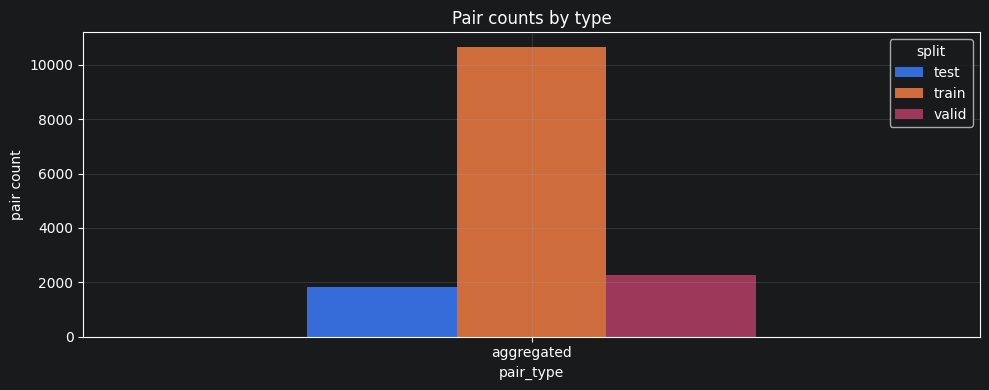

In [48]:
pair_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    pair_type_counter = Counter(pair.pair_type for group in groups for pair in group.pairs)
    weights_by_type = defaultdict(list)
    for group in groups:
        for pair in group.pairs:
            weights_by_type[pair.pair_type].append(pair.weight_raw)
    for pair_type, count in pair_type_counter.items():
        weights = weights_by_type[pair_type]
        pair_rows.append(
            {
                "split": split_name,
                "pair_type": pair_type,
                "pairs": count,
                "weight_min": round(min(weights), 4),
                "weight_mean": round(sum(weights) / len(weights), 4),
                "weight_max": round(max(weights), 4),
            }
        )

pair_frame = show_table(pair_rows, "pair 类型与权重分布", "pairs")
if pd is not None:
    pair_frame.pivot(index="pair_type", columns="split", values="pairs").fillna(0).plot(kind="bar", figsize=(10, 4))
    plt.title("Pair counts by type")
    plt.ylabel("pair count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### 最近 5 个 epoch

,epoch,lr,train/loss/goodness,train/loss/ranking,train/loss/reason,train/loss/total,valid/acceptedReasonFalsePositiveRate@issueThreshold,valid/goodnessAccuracy@0.5,valid/goodnessAuc,valid/goodnessPrAuc,...,valid/reasonAuc/LOW_ROUTE_DIVERSITY,valid/reasonAuc/REPETITIVE_POI_TYPE,valid/reasonAuc/WEAK_GOAL_FIT,valid/reasonConditionalMacroF1@0.5,valid/reasonConditionalMicroF1@0.5,valid/reasonConditionalPerCodeAucMacro,valid/reasonTopIssueHitRate,valid/top1Accuracy,valid/top2HitRate,valid/weightedPairwiseAccuracy
0,8,0.000359,0.496422,0.398672,0.843323,0.780858,1.000000,0.694930,0.754254,0.708176,...,0.585423,0.594400,0.620305,0.453029,0.509889,0.662470,0.585284,0.482428,0.738019,0.770675
1,9,0.000275,0.482244,0.386944,0.837421,0.760033,1.000000,0.690559,0.753430,0.704319,...,0.587021,0.602103,0.613302,0.453758,0.509424,0.662468,0.598662,0.488818,0.731629,0.772349
2,10,0.000203,0.471694,0.367558,0.836497,0.734224,0.998168,0.697552,0.755158,0.706185,...,0.584006,0.610412,0.604533,0.448869,0.502146,0.662039,0.595318,0.482428,0.747604,0.763114
3,11,0.000147,0.459659,0.354775,0.838833,0.714454,0.998168,0.694930,0.755118,0.706163,...,0.585659,0.610251,0.611631,0.455714,0.511177,0.664089,0.613712,0.472843,0.734824,0.767888
4,12,0.000112,0.453395,0.345341,0.835583,0.700937,1.000000,0.689685,0.755115,0.704933,...,0.586701,0.612901,0.615976,0.455411,0.511944,0.664399,0.615385,0.466454,0.731629,0.770982


### 关键指标最佳 epoch

,metric,best_epoch,best_value
0,valid/loss/total,7,0.908613
1,valid/loss/ranking,7,0.494298
2,valid/loss/goodness,7,0.552410
3,valid/loss/reason,8,0.826464
4,valid/weightedPairwiseAccuracy,9,0.772349
5,valid/ndcg@3,9,0.861789
6,valid/reasonConditionalMicroF1@0.5,7,0.516872
7,valid/reasonConditionalPerCodeAucMacro,12,0.664399


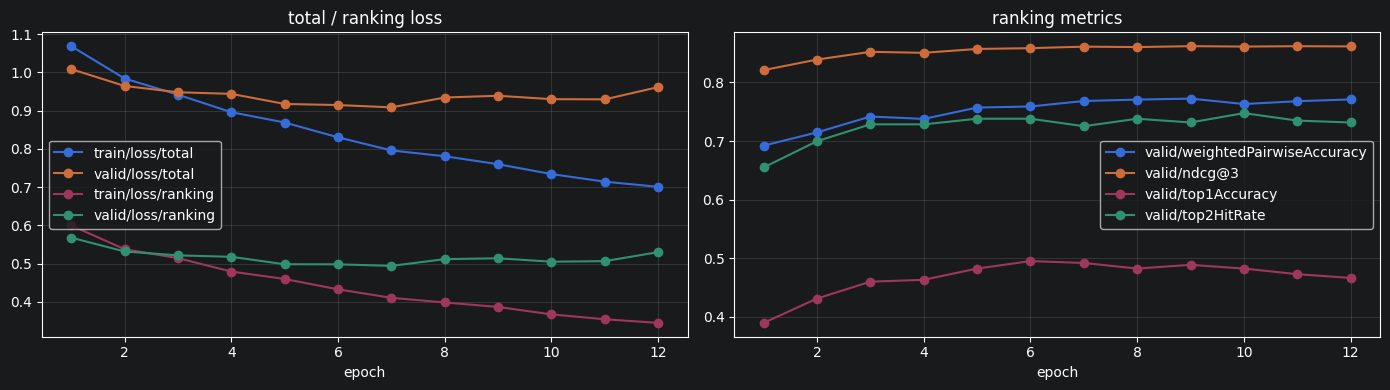

In [49]:
history_path = OUTPUT_DIR / "history.jsonl"
if not history_path.exists():
    display(Markdown(f"没有找到训练历史：`{history_path}`"))
else:
    history_rows = [json.loads(line) for line in history_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    history_frame = pd.DataFrame(history_rows) if pd is not None else history_rows
    show_table(history_rows[-5:], "最近 5 个 epoch")

    if pd is not None:
        metrics = [
            "valid/loss/total",
            "valid/loss/ranking",
            "valid/loss/goodness",
            "valid/loss/reason",
            "valid/weightedPairwiseAccuracy",
            "valid/ndcg@3",
            "valid/reasonConditionalMicroF1@0.5",
            "valid/reasonConditionalPerCodeAucMacro",
        ]
        best_rows = []
        for metric in metrics:
            if metric not in history_frame:
                continue
            idx = history_frame[metric].idxmin() if "/loss/" in metric else history_frame[metric].idxmax()
            best_rows.append({"metric": metric, "best_epoch": int(history_frame.loc[idx, "epoch"]), "best_value": history_frame.loc[idx, metric]})
        show_table(best_rows, "关键指标最佳 epoch")

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for key in ["train/loss/total", "valid/loss/total", "train/loss/ranking", "valid/loss/ranking"]:
            if key in history_frame:
                axes[0].plot(history_frame["epoch"], history_frame[key], marker="o", label=key)
        axes[0].set_title("total / ranking loss")
        axes[0].set_xlabel("epoch")
        axes[0].legend()

        for key in ["valid/weightedPairwiseAccuracy", "valid/ndcg@3", "valid/top1Accuracy", "valid/top2HitRate"]:
            if key in history_frame:
                axes[1].plot(history_frame["epoch"], history_frame[key], marker="o", label=key)
        axes[1].set_title("ranking metrics")
        axes[1].set_xlabel("epoch")
        axes[1].legend()
        plt.tight_layout()
        plt.show()


### 当前模型 reason 分数阈值诊断

,split,accepted_routes,accepted_runtime_issue_rate,accepted_max_reason_p50,accepted_max_reason_p90,accepted_max_reason_>=0.5,accepted_max_reason_>=0.8,rejected_labeled_reason_p50,rejected_labeled_reason_p90
0,train,2439,0.2091,0.6060,0.6625,0.9971,0.0439,0.6200,0.8997
1,valid,524,0.2137,0.6076,0.6589,0.9962,0.0344,0.6171,0.8944
2,test,421,0.2233,0.6065,0.6794,0.9952,0.0475,0.6283,0.9146


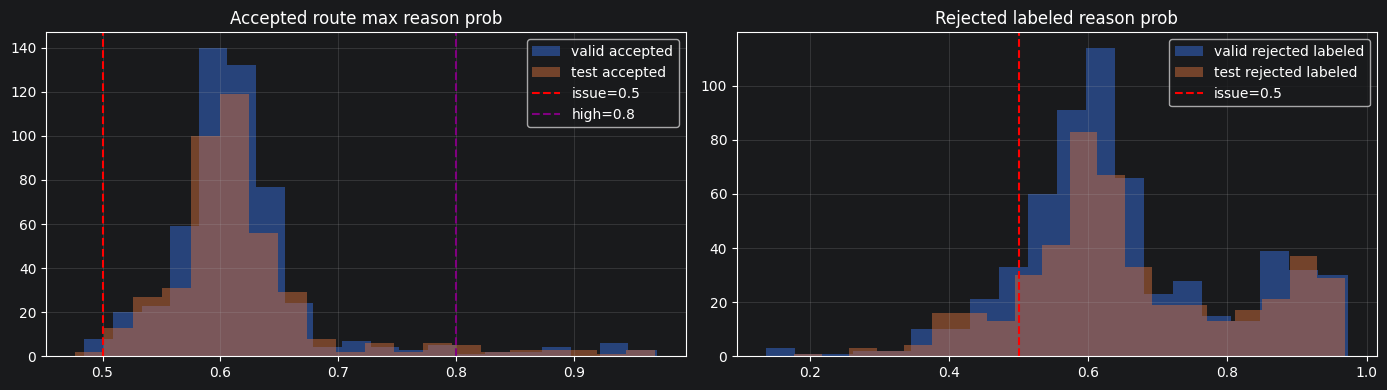

In [50]:
def percentile(values: list[float], q: float) -> float:
    if not values:
        return 0.0
    ordered = sorted(values)
    pos = (len(ordered) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(ordered) - 1)
    frac = pos - lo
    return ordered[lo] * (1 - frac) + ordered[hi] * frac


def model_config_from_checkpoint(payload: dict) -> RoutePreferenceModelConfig:
    config = payload["modelConfig"]
    return RoutePreferenceModelConfig(
        route_derived_dim=config["routeDerivedDim"],
        context_cross_dim=config["contextCrossDim"],
        intra_set_dim=config.get("intraSetDim", 0),
        stop_dim=config["stopDim"],
        segment_dim=config["segmentDim"],
        max_stops=config["maxStops"],
        max_segments=config["maxSegments"],
        hidden_dim=config["hiddenDim"],
        dropout=config["dropout"],
        reason_hidden_dim=config["reasonHiddenDim"],
        reason_count=config["reasonCount"],
    )


def current_model_reason_distribution(groups):
    checkpoint_path = OUTPUT_DIR / "route-preference.pt"
    if not checkpoint_path.exists():
        return None
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = RoutePreferenceModel(model_config_from_checkpoint(checkpoint))
    model.load_state_dict(checkpoint["stateDict"])
    model.eval()

    rows = []
    with torch.no_grad():
        for split_name, split_groups in groups.items():
            for group in split_groups:
                batch = next(iter_batches((group,), 1, shuffle=False, seed=SEED, device=torch.device("cpu")))
                output = model(
                    batch.stop_matrix,
                    batch.segment_matrix,
                    batch.route_derived_vector,
                    batch.context_cross_vector,
                    batch.intra_set_vector,
                )
                goodness_probs = torch.sigmoid(output.route_goodness_logit).cpu().tolist()
                reason_probs = torch.sigmoid(output.reason_code_logits).cpu().tolist()
                for index, item in enumerate(group.items):
                    max_reason = max(reason_probs[index]) if reason_probs[index] else 0.0
                    labeled_reason_scores = [reason_probs[index][code_index] for code_index, value in enumerate(item.reason_labels) if value >= 0.5]
                    runtime_threshold = DEFAULT_HIGH_ISSUE_THRESHOLD if goodness_probs[index] >= DEFAULT_GOOD_ROUTE_THRESHOLD else DEFAULT_ISSUE_THRESHOLD
                    rows.append(
                        {
                            "split": split_name,
                            "candidate_set_id": group.candidate_set_id,
                            "route_code": item.route_code,
                            "is_accepted": item.is_accepted,
                            "is_rejected": item.is_rejected,
                            "goodness_prob": goodness_probs[index],
                            "max_reason_prob": max_reason,
                            "max_labeled_reason_prob": max(labeled_reason_scores) if labeled_reason_scores else None,
                            "runtime_has_issue": max_reason >= runtime_threshold,
                        }
                    )
    return rows


score_rows = current_model_reason_distribution(SPLIT_GROUPS)
if score_rows is None:
    display(Markdown(f"没有找到当前模型：`{OUTPUT_DIR / 'route-preference.pt'}`"))
else:
    summary_rows = []
    for split_name in ["train", "valid", "test"]:
        accepted = [row for row in score_rows if row["split"] == split_name and row["is_accepted"]]
        rejected = [row for row in score_rows if row["split"] == split_name and row["is_rejected"]]
        accepted_max = [row["max_reason_prob"] for row in accepted]
        rejected_labeled = [row["max_labeled_reason_prob"] for row in rejected if row["max_labeled_reason_prob"] is not None]
        summary_rows.append(
            {
                "split": split_name,
                "accepted_routes": len(accepted),
                "accepted_runtime_issue_rate": round(sum(row["runtime_has_issue"] for row in accepted) / len(accepted), 4) if accepted else 0.0,
                "accepted_max_reason_p50": round(percentile(accepted_max, 0.50), 4),
                "accepted_max_reason_p90": round(percentile(accepted_max, 0.90), 4),
                "accepted_max_reason_>=0.5": round(sum(value >= 0.5 for value in accepted_max) / len(accepted_max), 4) if accepted_max else 0.0,
                "accepted_max_reason_>=0.8": round(sum(value >= 0.8 for value in accepted_max) / len(accepted_max), 4) if accepted_max else 0.0,
                "rejected_labeled_reason_p50": round(percentile(rejected_labeled, 0.50), 4),
                "rejected_labeled_reason_p90": round(percentile(rejected_labeled, 0.90), 4),
            }
        )
    show_table(summary_rows, "当前模型 reason 分数阈值诊断")

    if pd is not None:
        score_frame = pd.DataFrame(score_rows)
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for split_name in ["valid", "test"]:
            values = score_frame[(score_frame["split"] == split_name) & (score_frame["is_accepted"] == True)]["max_reason_prob"]
            axes[0].hist(values, bins=20, alpha=0.5, label=f"{split_name} accepted")
        axes[0].axvline(DEFAULT_ISSUE_THRESHOLD, color="red", linestyle="--", label="issue=0.5")
        axes[0].axvline(DEFAULT_HIGH_ISSUE_THRESHOLD, color="purple", linestyle="--", label="high=0.8")
        axes[0].set_title("Accepted route max reason prob")
        axes[0].legend()

        for split_name in ["valid", "test"]:
            values = score_frame[(score_frame["split"] == split_name) & score_frame["max_labeled_reason_prob"].notna()]["max_labeled_reason_prob"]
            axes[1].hist(values, bins=20, alpha=0.5, label=f"{split_name} rejected labeled")
        axes[1].axvline(DEFAULT_ISSUE_THRESHOLD, color="red", linestyle="--", label="issue=0.5")
        axes[1].set_title("Rejected labeled reason prob")
        axes[1].legend()
        plt.tight_layout()
        plt.show()


## 如何解读

- 如果 train split 的某个 reason code 正样本少于 30，优先补该 code 的数据，不要靠调参硬救。
- 如果 candidate set 数量很少，优先补新的 candidate set；route 数多但 candidate set 少，泛化仍然不稳。
- 如果 train 指标继续涨、valid 指标早早见顶，优先使用 `best_metric` / early stopping，而不是继续加大模型。
- `acceptedReasonFalsePositiveRate@issueThreshold` 使用 0.5 阈值，是偏严格的诊断；实际预测对 good route 会用 `HIGH_ISSUE_THRESHOLD=0.8`。
